In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank_customer_dataset_1500.xlsx to bank_customer_dataset_1500.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("bank_customer_dataset_1500.xlsx")

print(df.head())
print(df.info())

   age       job     education  balance  campaign  pdays  previous poutcome
0   59   student    highschool    11996         4     60         4  unknown
1   48   student      graduate    14380         3    200         6  unknown
2   32  services    highschool    10556         4    120         6  success
3   48     admin  postgraduate     8126         3     60         4  unknown
4   59  services      graduate      911         4    200         0  failure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        1500 non-null   int64 
 1   job        1500 non-null   object
 2   education  1500 non-null   object
 3   balance    1500 non-null   int64 
 4   campaign   1500 non-null   int64 
 5   pdays      1500 non-null   int64 
 6   previous   1500 non-null   int64 
 7   poutcome   1500 non-null   object
dtypes: int64(5), object(3)
memory usage: 93.9+ 

In [3]:
from sklearn.preprocessing import LabelEncoder

# check column names first
print(df.columns)

Index(['age', 'job', 'education', 'balance', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='object')


In [5]:
# STEP 4: Feature Selection (FINAL VERSION)

# clean column names (remove spaces if any)
df.columns = df.columns.str.strip()

# select required features
features = ['age', 'balance', 'campaign', 'pdays', 'previous']

# create feature dataset
X = df[features].copy()

# display output
print("Selected Features:", features)
print(X.head())

Selected Features: ['age', 'balance', 'campaign', 'pdays', 'previous']
   age  balance  campaign  pdays  previous
0   59    11996         4     60         4
1   48    14380         3    200         6
2   32    10556         4    120         6
3   48     8126         3     60         4
4   59      911         4    200         0


In [6]:
# STEP 5: Feature Scaling

from sklearn.preprocessing import StandardScaler

# initialize scaler
scaler = StandardScaler()

# apply scaling
X_scaled = scaler.fit_transform(X)

# convert back to DataFrame (for better understanding)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# display output
print("Scaled Data:")
print(X_scaled_df.head())

Scaled Data:
        age   balance  campaign     pdays  previous
0  1.367318  1.043527  1.338193 -0.597910  0.471739
1  0.553790  1.624832  0.445668 -0.128810  1.464872
2 -0.629522  0.692403  1.338193 -0.396867  1.464872
3  0.553790  0.099881  0.445668 -0.597910  0.471739
4  1.367318 -1.659398  1.338193 -0.128810 -1.514529


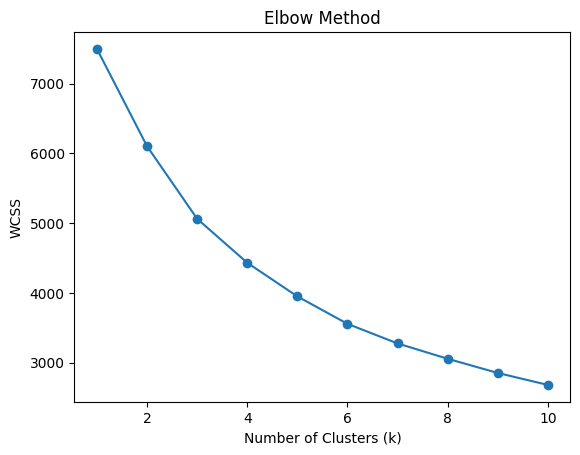

In [7]:
# STEP 6: Elbow Method to find optimal k

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []  # list to store WCSS values

# try different number of clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plot graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [8]:
# STEP 7: Apply K-Means Clustering

from sklearn.cluster import KMeans

# create model with optimal clusters (k = 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# fit model and predict clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

# display output
print("Clustered Data:")
print(df.head())

Clustered Data:
   age       job     education  balance  campaign  pdays  previous poutcome  \
0   59   student    highschool    11996         4     60         4  unknown   
1   48   student      graduate    14380         3    200         6  unknown   
2   32  services    highschool    10556         4    120         6  success   
3   48     admin  postgraduate     8126         3     60         4  unknown   
4   59  services      graduate      911         4    200         0  failure   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


In [9]:
# STEP 8: Cluster Analysis

# group data by cluster and calculate mean values
cluster_analysis = df.groupby('cluster')[['age','balance','campaign','pdays','previous']].mean()

# display result
print("Cluster Analysis (Mean Values):")
print(cluster_analysis)

Cluster Analysis (Mean Values):
               age      balance  campaign       pdays  previous
cluster                                                        
0        40.703876  7468.003101  1.508527  133.596899  3.024806
1        40.034380  7687.343797  3.500747  128.071749  3.103139
2        41.564516  8682.112903  2.344086  999.000000  2.946237


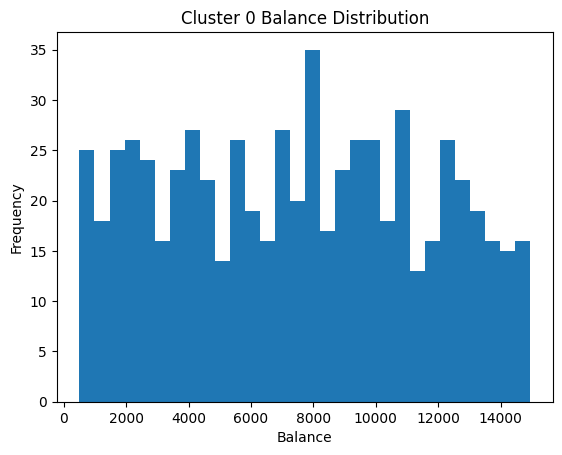

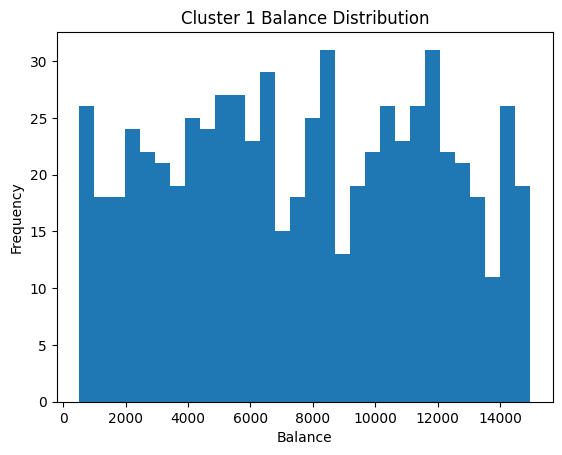

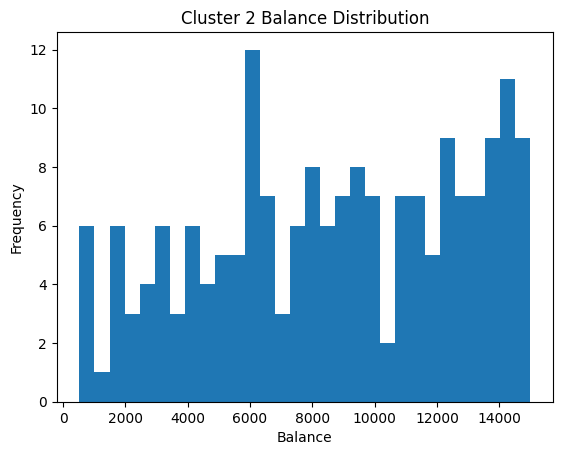

In [10]:
# STEP 9: Histogram Visualization for each cluster

import matplotlib.pyplot as plt

# plot histogram for each cluster
for i in range(3):
    plt.figure()

    # filter data for each cluster
    cluster_data = df[df['cluster'] == i]['balance']

    # plot histogram
    plt.hist(cluster_data, bins=30)

    plt.title(f"Cluster {i} Balance Distribution")
    plt.xlabel("Balance")
    plt.ylabel("Frequency")

    plt.show()

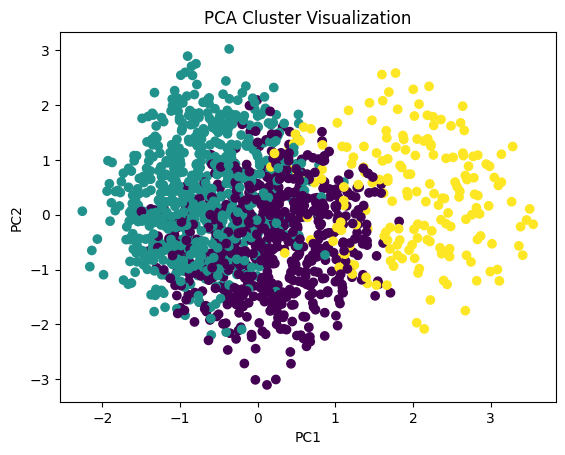

In [11]:
# STEP 10: PCA + Scatter Plot

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# apply PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# create new columns
df['PC1'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]

# scatter plot
plt.figure()

plt.scatter(df['PC1'], df['PC2'], c=df['cluster'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Cluster Visualization")

plt.show()

In [12]:
# PCA Variance Explained

explained_variance = pca.explained_variance_ratio_

print("Variance by PC1:", explained_variance[0])
print("Variance by PC2:", explained_variance[1])
print("Total Variance Captured:", sum(explained_variance))

Variance by PC1: 0.2230389407144618
Variance by PC2: 0.21349036884133082
Total Variance Captured: 0.4365293095557926


In [13]:
# STEP 11: Save Final Output Files

# 1. Save clustered data (original + cluster + PCA columns)
df.to_csv("clustered_data.csv", index=False)

# 2. Create separate PCA result file
import pandas as pd

pca_df = pd.DataFrame({
    'PC1': df['PC1'],
    'PC2': df['PC2'],
    'cluster': df['cluster']
})

# save PCA file
pca_df.to_csv("pca_results.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


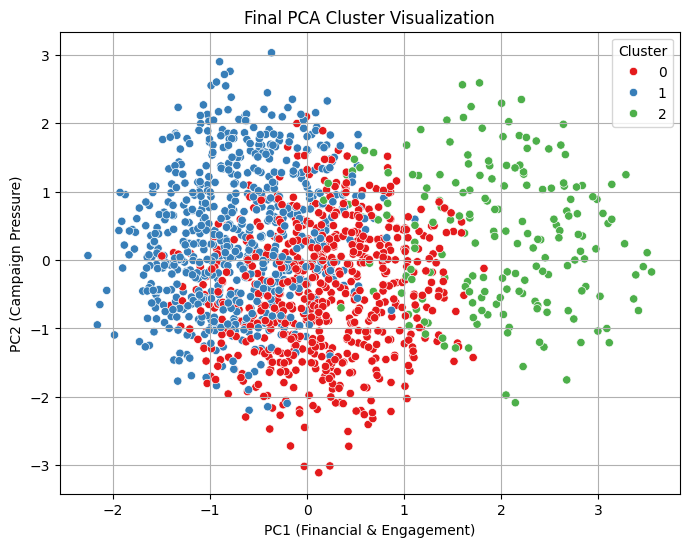

In [14]:
# STEP 12: Final PCA Visualization (Advanced Scatter Plot)

import seaborn as sns
import matplotlib.pyplot as plt

# create plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['PC1'],
    y=df['PC2'],
    hue=df['cluster'],   # color based on cluster
    palette='Set1'
)

plt.title("Final PCA Cluster Visualization")
plt.xlabel("PC1 (Financial & Engagement)")
plt.ylabel("PC2 (Campaign Pressure)")

plt.legend(title="Cluster")
plt.grid(True)

plt.show()

In [15]:
# STEP 13: Final Summary of Clusters

# calculate cluster size (number of customers in each cluster)
cluster_count = df['cluster'].value_counts().sort_index()

# calculate average values per cluster
cluster_summary = df.groupby('cluster')[['age','balance','campaign','pdays','previous']].mean()

print("🔹 Cluster Count:")
print(cluster_count)

print("\n🔹 Cluster Summary (Mean Values):")
print(cluster_summary)

🔹 Cluster Count:
cluster
0    645
1    669
2    186
Name: count, dtype: int64

🔹 Cluster Summary (Mean Values):
               age      balance  campaign       pdays  previous
cluster                                                        
0        40.703876  7468.003101  1.508527  133.596899  3.024806
1        40.034380  7687.343797  3.500747  128.071749  3.103139
2        41.564516  8682.112903  2.344086  999.000000  2.946237


In [16]:
# STEP 14: Download output files from Google Colab

from google.colab import files

# download clustered data file
files.download("clustered_data.csv")

# download PCA results file
files.download("pca_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# STEP 15: Evaluate Clustering using Silhouette Score

from sklearn.metrics import silhouette_score

# calculate silhouette score
score = silhouette_score(X_scaled, df['cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.20460992194705693
